In [133]:
# Part 1: Same author
# The Murder of Roger Ackroyd: https://www.gutenberg.org/ebooks/69087
# The Mystery of the Blue Train: https://www.gutenberg.org/ebooks/72824
# Part 2: Different authors
# Dracula: https://www.gutenberg.org/ebooks/345
# My plan is to compare these books by building off of the example code given in the mini project notebook

In [134]:
import requests
import re
import nltk
from bs4 import BeautifulSoup
from collections import Counter
import operator
import matplotlib.pyplot as plt
import numpy as np

In [135]:
stop_words = nltk.corpus.stopwords.words('english') + [
    'ut', '\'re', '.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
    '"', '-', '}', '{', '&', '|', u'\u2014',
    'dont', 'im', 'its', 'youre', 'thats', 'theres', 'hes', 'shes', 'ive', 'youll', 'ill'
]

In [136]:
def cleanHtml(html):
    soup = BeautifulSoup(html, 'html.parser')
    return soup.get_text()


def cleanWord(w):
    wn = re.sub('[,\"\“\”\'\’\.\&\|:@>*;/=]', "", w)
    return re.sub('^[0-9\.]*$', "", wn)

In [137]:
def strip_gutenberg_boilerplate(text):
    start_marker = re.search(r'\*\*\* START OF.*?\*\*\*', text, re.IGNORECASE | re.DOTALL)
    end_marker = re.search(r'\*\*\* END OF.*?\*\*\*', text, re.IGNORECASE | re.DOTALL)
    start = start_marker.end() if start_marker else 0
    end = end_marker.start() if end_marker else len(text)
    return text[start:end]

def get_wf(URL):
    r = requests.get(URL)

    t = strip_gutenberg_boilerplate(r.text)
    t = cleanHtml(r.text).lower()

    wds = re.split('\s+', t)

    for i in range(len(wds)):
        wds[i] = cleanWord(wds[i])
    wds = [w for w in wds if w]
    wf = Counter(wds)

    for k in stop_words:
        wf.pop(k, None)

    tw = 0
    for w in wf:
        tw += wf[w]

    wfs = sorted(wf.items(), key=operator.itemgetter(1), reverse=True)

    return wfs, tw

In [138]:
roger_url = 'https://www.gutenberg.org/ebooks/69087.txt.utf-8'
blue_train_url = 'https://www.gutenberg.org/ebooks/72824.txt.utf-8'
dracula_url = 'https://www.gutenberg.org/ebooks/345.txt.utf-8'

In [139]:
(wf_roger, tw_roger) = get_wf(roger_url)
(wf_blue_train, tw_blue_train) = get_wf(blue_train_url)
(wf_dracula, tw_dracula) = get_wf(dracula_url)

In [140]:
print("Roger Ackroyd:", tw_roger)
print("Blue Train:", tw_blue_train)
print("Dracula:", tw_dracula)

Roger Ackroyd: 36253
Blue Train: 36011
Dracula: 73839


In [141]:
print("The Murder of Roger Ackroyd")

for i in range(50):
    print(wf_roger[i][0], wf_roger[i][1])

The Murder of Roger Ackroyd
said 795
poirot 423
ackroyd 330
one 284
caroline 206
know 205
mr 182
ralph 178
miss 172
man 169
flora 169
see 168
inspector 165
little 165
would 161
must 158
mrs 154
think 154
say 140
asked 140
parker 139
went 131
yes 116
blunt 116
well 113
time 113
us 112
like 112
door 110
came 110
last 110
something 109
come 105
tell 103
quite 100
raymond 99
got 99
could 97
paton 97
good 95
two 92
never 90
might 89
way 89
things 89
back 89
project 88
looked 87
may 85
go 84


In [142]:
print("The Mystery of the Blue Train")

for i in range(50):
    print(wf_blue_train[i][0], wf_blue_train[i][1])

The Mystery of the Blue Train
said 817
poirot 453
one 304
van 293
katherine 285
aldin 267
would 216
know 198
man 195
kettering 184
little 168
yes 166
say 161
looked 157
derek 155
monsieur 153
think 153
comte 149
knighton 142
mademoiselle 142
see 142
train 135
well 131
like 125
back 123
lady 122
good 122
came 109
two 106
something 106
went 105
tell 103
face 102
time 99
must 99
come 99
go 97
mr 94
ruth 94
head 93
could 92
things 92
might 90
project 88
murmured 88
got 86
woman 84
much 84
lenox 81
eyes 81


In [143]:
print("Dracula")

for i in range(50):
    print(wf_dracula[i][0], wf_dracula[i][1])

Dracula
could 490
one 489
said 461
us 447
must 447
would 428
shall 426
may 410
see 385
know 382
time 364
come 324
van 322
came 305
went 298
helsing 292
go 275
like 273
back 256
seemed 243
even 234
well 227
took 224
dear 217
think 217
though 216
saw 216
much 214
way 212
good 209
man 208
lucy 205
night 203
room 203
face 200
hand 200
made 195
door 194
mina 192
poor 191
tell 190
old 187
eyes 186
away 185
looked 184
great 181
friend 178
work 176
jonathan 175
sleep 173


In [144]:
def to_rate_dict(wf, tw):
    return {w: c / tw * 1000 for w, c in wf}

rate_roger = to_rate_dict(wf_roger, tw_roger)
rate_blue = to_rate_dict(wf_blue_train, tw_blue_train)
rate_dracula = to_rate_dict(wf_dracula, tw_dracula)

In [145]:
common_words = set(rate_roger) & set(rate_blue) & set(rate_dracula)
candidate_words = ['said', 'one', 'know', 'man', 'see', 'would', 'must', 'think',
                    'say', 'went', 'yes', 'time', 'us', 'like', 'came', 'well',
                    'come', 'tell', 'could', 'good', 'might', 'way', 'back',
                    'looked', 'go', 'much', 'little']

compare_words = [w for w in candidate_words if w in common_words]

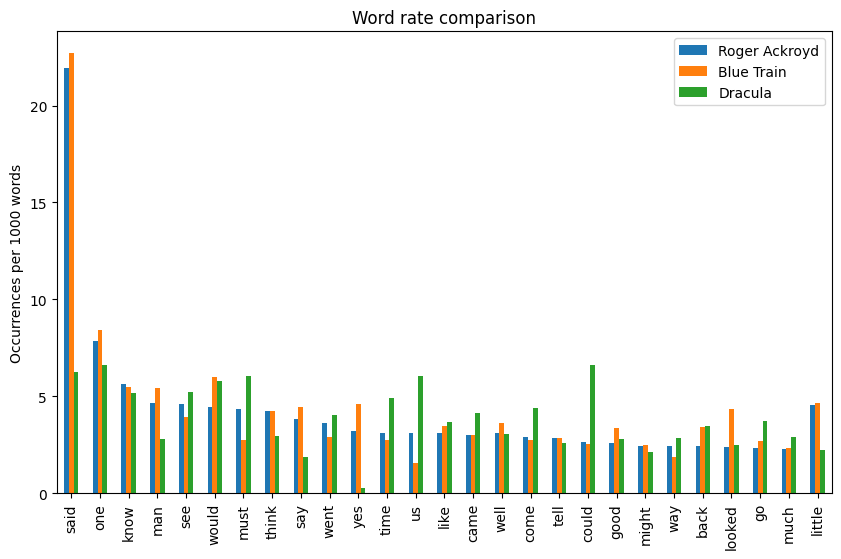

In [146]:
import pandas as pd

df = pd.DataFrame({
    'Roger Ackroyd': [rate_roger.get(w, 0) for w in compare_words],
    'Blue Train':    [rate_blue.get(w, 0) for w in compare_words],
    'Dracula':       [rate_dracula.get(w, 0) for w in compare_words],
}, index=compare_words)

df.plot(kind='bar', figsize=(10,6))
plt.ylabel('Occurrences per 1000 words')
plt.title('Word rate comparison')
plt.show()

In [147]:
# import matplotlib.pyplot as plt
# from scipy.stats import spearmanr

# ranks_roger = {w: i for i, (w, c) in enumerate(wf_roger)}
# ranks_dracula = {w: i for i, (w, c) in enumerate(wf_dracula)}

# shared = list(set(ranks_roger) & set(ranks_dracula))
# x = [ranks_roger[w] for w in shared]
# y = [ranks_dracula[w] for w in shared]
# rho, pval = spearmanr(x, y)

# plt.figure(figsize=(6,6))
# plt.scatter(x, y, alpha=0.4, s=15)
# plt.xlabel('Rank in Roger Ackroyd')
# plt.ylabel('Rank in Dracula')
# plt.title(f'Roger Ackroyd vs Dracula\nSpearman ρ = {rho:.3f}, p = {pval:.2e}')
# plt.plot([0, max(x + y)], [0, max(x + y)], 'r--', alpha=0.5, label='Perfect agreement')
# plt.legend()
# plt.show()

# print(f"rho = {rho:.4f}, p-value = {pval:.4e}")

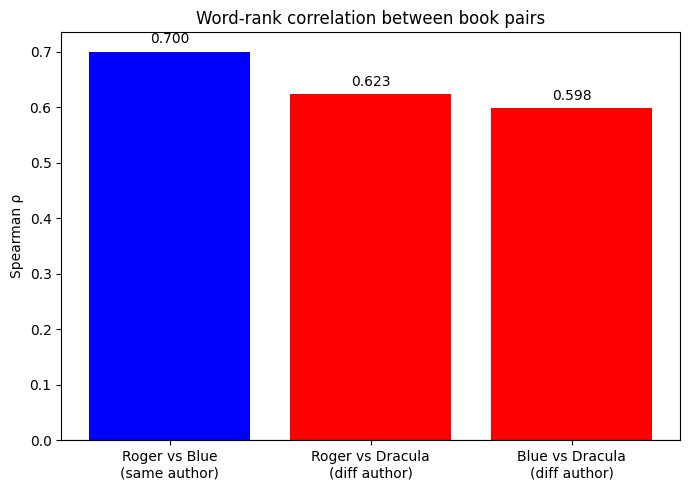

Roger vs Blue: rho = 0.6999, p = 0.0000e+00
Roger vs Dracula: rho = 0.6232, p = 0.0000e+00
Blue vs Dracula: rho = 0.5978, p = 0.0000e+00


In [149]:
ranks_blue = {w: i for i, (w, c) in enumerate(wf_blue_train)}

pairs = [
    ('Roger vs Blue\n(same author)', ranks_roger, ranks_blue),
    ('Roger vs Dracula\n(diff author)', ranks_roger, ranks_dracula),
    ('Blue vs Dracula\n(diff author)', ranks_blue, ranks_dracula),
]

labels, rhos, pvals = [], [], []
for name, ra, rb in pairs:
    shared = list(set(ra) & set(rb))
    rho, pval = spearmanr([ra[w] for w in shared], [rb[w] for w in shared])
    labels.append(name)
    rhos.append(rho)
    pvals.append(pval)

colors = ['blue', 'red', 'red']

plt.figure(figsize=(7,5))
bars = plt.bar(labels, rhos, color=colors)
plt.ylabel('Spearman ρ')
plt.title('Word-rank correlation between book pairs')
plt.axhline(0, color='black', linewidth=0.8)

for bar, rho in zip(bars, rhos):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{rho:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

for name, rho, pval in zip(labels, rhos, pvals):
    print(f"{name.splitlines()[0]}: rho = {rho:.4f}, p = {pval:.4e}")

# Assignment 1

1. Compare word frequencies between two works of a single author.  
When comparing word frequencies, we see many similarities; the primary similarity found between the two books written by Agatha Christie is her prominent usage of the word "said." This likely shows a propensity for including a lot of dialogue in her books, which makes sense in the murder mysteries that she writes.
1. Compare word frequencies between works of two authors.  
On the other hand, when we look at the comparison between Christie's books and *Dracula*, we find a larger difference. As seen in the bar graph above, Christie's two books shared a similarity value of 0.7, while Dracula shared lower values of 0.623 and 0.598. Because of how prose is structured in English, the three books are still quite similar, but there is a clear difference in the frequency between authors.
1. Are there some words preferred by one author but used less frequently by another author?  
In the bar graph showing word-rate comparison, we see that many words are used about the same between the two authors; however, the largest differences are that Christie prefers "said" much more than Stoker, while Stoker prefers to use "us" and "could" much more than Christie does.